In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import vectorbt as vbt
import sys
from tqdm.auto import tqdm

sys.path.insert(0, str(Path('.').resolve().parent))
from dema_strat import load_ohlcv, vbt_frame, free
from constants import CASH, COMMISSION, SESSIONS

TABLE_NAME = "f1_session"
SMOOTH_PERIOD = 12
RISK_PER_TRADE = 100.0


In [2]:
def load_data(file_path, *, verbose=False, use_vwap=False):
    return load_ohlcv(file_path, use_cache=True, add_vwap=use_vwap, verbose=verbose)

def session_mask(index, session):
    start = pd.Timestamp(session["start"]).time()
    end = pd.Timestamp(session["end"]).time()
    tod = np.array(index.to_series().dt.time.values)
    if start <= end:
        return (tod >= start) & (tod < end)
    return (tod >= start) | (tod < end)

def make_signals(data, n1=9, atr_period=14, sl_mult=1.0, rr_ratio=0.5, use_vwap=False, smooth_period=SMOOTH_PERIOD):
    close = data["Close"]
    high = data["High"]
    low = data["Low"]

    ema1 = vbt.indicators.MA.run(close, window=n1, ewm=True)
    smoothed = vbt.indicators.MA.run(ema1.ma, window=smooth_period, ewm=True)
    atr = vbt.indicators.ATR.run(high, low, close, window=atr_period)

    sl_dist = sl_mult * atr.atr
    tp_dist = rr_ratio * sl_dist
    sl_pct = sl_dist / close
    tp_pct = tp_dist / close

    long_mask = (smoothed.ma > ema1.ma) & np.isfinite(atr.atr) & (atr.atr > 0)
    short_mask = (ema1.ma > smoothed.ma) & np.isfinite(atr.atr) & (atr.atr > 0)

    if use_vwap:
        long_mask = long_mask & (close > data["VWAP"])
        short_mask = short_mask & (close < data["VWAP"])

    return pd.DataFrame({
        "ema1": ema1.ma,
        "smoothed": smoothed.ma,
        "atr": atr.atr,
        "sl_pct": sl_pct,
        "tp_pct": tp_pct,
        "long": long_mask,
        "short": short_mask,
    })

def run_backtest(data, n1=9, atr_period=14, sl_mult=1.0, rr_ratio=0.5, use_vwap=False, smooth_period=SMOOTH_PERIOD, session=None):
    signals = make_signals(data, n1=n1, atr_period=atr_period, sl_mult=sl_mult, rr_ratio=rr_ratio, use_vwap=use_vwap, smooth_period=smooth_period)
    freq = data.index.to_series().diff().median()

    long_signal = signals["long"].to_numpy(dtype=bool)
    short_signal = signals["short"].to_numpy(dtype=bool)

    n = len(data)
    in_session = np.ones(n, dtype=bool)
    session_end = np.zeros(n, dtype=bool)
    if session is not None:
        in_session = session_mask(data.index, session)
        next_in = np.empty(n, dtype=bool)
        next_in[:-1] = in_session[1:]
        next_in[-1] = False
        session_end = in_session & ~next_in

    long_signal = long_signal & in_session & ~session_end
    short_signal = short_signal & in_session & ~session_end
    exits_long = short_signal | session_end
    exits_short = long_signal | session_end

    close_np = data["Close"].to_numpy(dtype=np.float64)

    sl_pct_np = signals["sl_pct"].to_numpy(dtype=np.float64)
    size_value = np.where(sl_pct_np > 0, RISK_PER_TRADE / sl_pct_np, 0.0)

    portfolio = vbt.Portfolio.from_signals(
        close=close_np,
        entries=long_signal,
        exits=exits_long,
        short_entries=short_signal,
        short_exits=exits_short,
        init_cash=CASH,
        fees=COMMISSION,
        size=size_value,
        size_type="value",
        freq=freq,
        sl_stop=signals["sl_pct"].to_numpy(dtype=np.float64),
        tp_stop=signals["tp_pct"].to_numpy(dtype=np.float64),
    )

    return portfolio, portfolio.stats(), signals

In [3]:
file_path = Path("~/market_data/XAUUSD/XAUUSD_M15.csv").expanduser()
data = load_data(file_path, verbose=True)

portfolio, stats, signals = run_backtest(
    data,
    n1=5,
    rr_ratio=1,
    atr_period=18,
    session=SESSIONS[1],
    sl_mult=3,
    use_vwap=1,
    smooth_period=12,
)
print(stats)

win_rate = float(stats["Win Rate [%]"]) / 100
expectancy = float(stats["Expectancy"])
avg_win = float(stats["Avg Winning Trade [%]"])
avg_loss = float(stats["Avg Losing Trade [%]"])
total_trades = int(stats["Total Trades"])

print("\n=== Strategy Statistics ===")
print(f"Win Rate: {win_rate:.2%}")
print(f"Expectancy: ${expectancy:.2f} per trade")
print(f"Avg Win: {avg_win:.2%}")
print(f"Avg Loss: {avg_loss:.2%}")
print(f"Total Trades: {total_trades}")

risk_per_trade = 100.0
avg_loss_dollars = risk_per_trade
avg_win_dollars = (expectancy + (1 - win_rate) * avg_loss_dollars) / win_rate
print("\n=== Trade Distribution (Risk=$100) ===")
print(f"Avg Loss: ${avg_loss_dollars:.2f}")
print(f"Avg Win: ${avg_win_dollars:.2f}")
print(f"R-multiple: {avg_win_dollars/avg_loss_dollars:.2f}R")

[loader] cache hit: XAUUSD_M15__cache_v1.parquet
Start                                                 0
End                                              139917
Period                               1457 days 11:30:00
Start Value                                     50000.0
End Value                                  49119.857714
Total Return [%]                              -1.760285
Benchmark Return [%]                         184.221285
Max Gross Exposure [%]                       160.536787
Total Fees Paid                            15595.061732
Max Drawdown [%]                               7.903592
Max Drawdown Duration                 578 days 16:30:00
Total Trades                                       1969
Total Closed Trades                                1969
Total Open Trades                                     0
Open Trade PnL                                      0.0
Win Rate [%]                                  45.810056
Best Trade [%]                                 5.487051

In [4]:
WIN_RATE = win_rate
AVG_WIN = avg_win_dollars
AVG_LOSS = avg_loss_dollars
RISK_PER_TRADE = 100.0
TRADES_PER_DAY = 2

print("Blind MC Parameters:")
print(f"  Win Rate: {WIN_RATE:.2%}")
print(f"  Avg Win: ${AVG_WIN:.2f}")
print(f"  Avg Loss: ${AVG_LOSS:.2f}")
print(f"  Trades/Day: {TRADES_PER_DAY}")
exp_trade = WIN_RATE * AVG_WIN - (1-WIN_RATE) * AVG_LOSS
print(f"  Expectancy per trade: ${exp_trade:.2f}")
print(f"  Expectancy per day: ${TRADES_PER_DAY * exp_trade:.2f}")

Blind MC Parameters:
  Win Rate: 45.81%
  Avg Win: $117.32
  Avg Loss: $100.00
  Trades/Day: 2
  Expectancy per trade: $-0.45
  Expectancy per day: $-0.89


In [5]:
class TopstepXCombine:
    def __init__(self, starting_balance=50000, profit_target=3000, max_loss_limit=2000,
                 consistency_target_pct=0.5, min_days=2):
        self.starting_balance = starting_balance
        self.profit_target = profit_target
        self.max_loss_limit = max_loss_limit
        self.consistency_target = profit_target * consistency_target_pct
        self.min_days = min_days
    
    def simulate(self, daily_pnls, seed=None):
        if seed is not None:
            np.random.seed(seed)
        
        balance = self.starting_balance
        mll = self.starting_balance - self.max_loss_limit
        days_traded = 0
        max_daily_profit = 0
        total_profit = 0
        
        for pnl in daily_pnls:
            balance += pnl
            total_profit += pnl
            days_traded += 1
            
            if pnl > max_daily_profit:
                max_daily_profit = pnl
            
            if balance <= mll:
                return {'passed': False, 'reason': 'MLL_hit', 'days': days_traded, 'balance': balance, 'total_profit': total_profit, 'max_daily_profit': max_daily_profit}
            
            new_mll = balance - self.max_loss_limit
            if new_mll > mll:
                mll = new_mll
            if mll >= self.starting_balance:
                mll = self.starting_balance
            
            if total_profit >= self.profit_target:
                if max_daily_profit < self.consistency_target:
                    if days_traded >= self.min_days:
                        return {'passed': True, 'reason': 'profit_target', 'days': days_traded, 'balance': balance, 'total_profit': total_profit, 'max_daily_profit': max_daily_profit}
                else:
                    return {'passed': False, 'reason': 'consistency_fail', 'days': days_traded, 'balance': balance, 'total_profit': total_profit, 'max_daily_profit': max_daily_profit}
        
        return {'passed': False, 'reason': 'insufficient_days', 'days': days_traded, 'balance': balance, 'total_profit': total_profit, 'max_daily_profit': max_daily_profit}

class TopstepXFA:
    def __init__(self, max_loss_limit=2000, target_profit=2000):
        self.max_loss_limit = max_loss_limit
        self.target_profit = target_profit
        self.mll = -max_loss_limit
    
    def simulate(self, daily_pnls, seed=None):
        if seed is not None:
            np.random.seed(seed + 1000000)
        
        balance = 0
        total_profit = 0
        days_traded = 0
        
        for pnl in daily_pnls:
            balance += pnl
            total_profit += pnl
            days_traded += 1
            
            if balance <= self.mll:
                return {'funded': False, 'reason': 'MLL_hit', 'days': days_traded, 'balance': balance, 'total_profit': total_profit}
            
            new_mll = balance - self.max_loss_limit
            if new_mll > self.mll:
                self.mll = new_mll
            if self.mll >= 0:
                self.mll = 0
            
            if total_profit >= self.target_profit:
                return {'funded': True, 'reason': 'target_reached', 'days': days_traded, 'balance': balance, 'total_profit': total_profit}
        
        return {'funded': False, 'reason': 'insufficient_profit', 'days': days_traded, 'balance': balance, 'total_profit': total_profit}

In [6]:
def generate_daily_pnl(seed, max_days=500):
    np.random.seed(seed)
    daily_pnls = []
    for _ in range(max_days):
        day_pnl = 0
        for _ in range(TRADES_PER_DAY):
            if np.random.random() < WIN_RATE:
                day_pnl += np.random.normal(AVG_WIN, AVG_WIN * 0.3)
            else:
                day_pnl -= np.random.normal(AVG_LOSS, AVG_LOSS * 0.3)
        daily_pnls.append(day_pnl)
    return np.array(daily_pnls)

sample = generate_daily_pnl(42, 30)
print(f"Sample 30 days: mean={sample.mean():.2f}, std={sample.std():.2f}")
print(f"Sample: {sample[:10]}")

Sample 30 days: mean=15.16, std=172.44
Sample: [ 206.72491331   -3.17766402  195.70639102  176.13330528    4.02923331
  -22.76911681   -4.49045612  246.85306701 -164.50077257   -2.43907782]


In [7]:
combine = TopstepXCombine()
xfa = TopstepXFA(target_profit=2000)

n_sims = 5000
max_days = 500
combine_results = []
xfa_results = []

for i in tqdm(range(n_sims), desc="Blind Monte Carlo"):
    daily_pnls = generate_daily_pnl(i, max_days)
    cr = combine.simulate(daily_pnls, seed=i)
    combine_results.append(cr)
    
    if cr['passed']:
        xr = xfa.simulate(daily_pnls[cr['days']:], seed=i)
        xfa_results.append(xr)
    else:
        xfa_results.append({'funded': False, 'reason': 'combine_failed', 'days': 0, 'balance': 0, 'total_profit': 0})

Blind Monte Carlo:   0%|          | 0/5000 [00:00<?, ?it/s]

In [8]:
combine_df = pd.DataFrame(combine_results)
xfa_df = pd.DataFrame(xfa_results)

pass_rate = combine_df['passed'].mean()
funded_rate = xfa_df['funded'].mean()
conditional_funded = xfa_df[combine_df['passed']]['funded'].mean() if combine_df['passed'].any() else 0

print(f"=== Blind Monte Carlo Results ({n_sims} simulations) ===")
print("\n--- Trading Combine (Evaluation) ---")
print(f"Pass Rate: {pass_rate:.2%} ({combine_df['passed'].sum()}/{n_sims})")
print("\nReasons for failure:")
print(combine_df[~combine_df['passed']]['reason'].value_counts())
if combine_df['passed'].any():
    print(f"\nDays to pass (successful): {combine_df[combine_df['passed']]['days'].mean():.1f} avg")
    print(f"Total profit at pass: ${combine_df[combine_df['passed']]['total_profit'].mean():.2f} avg")
    print(f"Max daily profit at pass: ${combine_df[combine_df['passed']]['max_daily_profit'].mean():.2f} avg")
    print(f"Consistency fail rate: {(combine_df['reason']=='consistency_fail').mean():.2%}")

print("\n--- Express Funded Account (XFA) ---")
print(f"Funded Rate (overall): {funded_rate:.2%} ({xfa_df['funded'].sum()}/{n_sims})")
print(f"Funded Rate (conditional on passing combine): {conditional_funded:.2%}")
print("\nXFA failure reasons:")
print(xfa_df[~xfa_df['funded']]['reason'].value_counts())
if xfa_df['funded'].any():
    print(f"Days to funded: {xfa_df[xfa_df['funded']]['days'].mean():.1f} avg")
    print(f"Total profit at funded: ${xfa_df[xfa_df['funded']]['total_profit'].mean():.2f} avg")

print("\n=== Summary ===")
print(f"Combine Pass Rate: {pass_rate:.2%}")
print(f"Funded Rate (overall): {funded_rate:.2%}")
print(f"Funded Rate (conditional): {conditional_funded:.2%}")
print(f"Expected value per combine attempt: ${pass_rate * conditional_funded * 2000:.2f}")

=== Blind Monte Carlo Results (5000 simulations) ===

--- Trading Combine (Evaluation) ---
Pass Rate: 22.38% (1119/5000)

Reasons for failure:
reason
MLL_hit              3848
insufficient_days      33
Name: count, dtype: int64

Days to pass (successful): 183.7 avg
Total profit at pass: $3090.14 avg
Max daily profit at pass: $344.24 avg
Consistency fail rate: 0.00%

--- Express Funded Account (XFA) ---
Funded Rate (overall): 1.26% (63/5000)
Funded Rate (conditional on passing combine): 5.63%

XFA failure reasons:
reason
combine_failed         3881
MLL_hit                1055
insufficient_profit       1
Name: count, dtype: int64
Days to funded: 67.8 avg
Total profit at funded: $2078.41 avg

=== Summary ===
Combine Pass Rate: 22.38%
Funded Rate (overall): 1.26%
Funded Rate (conditional): 5.63%
Expected value per combine attempt: $25.20


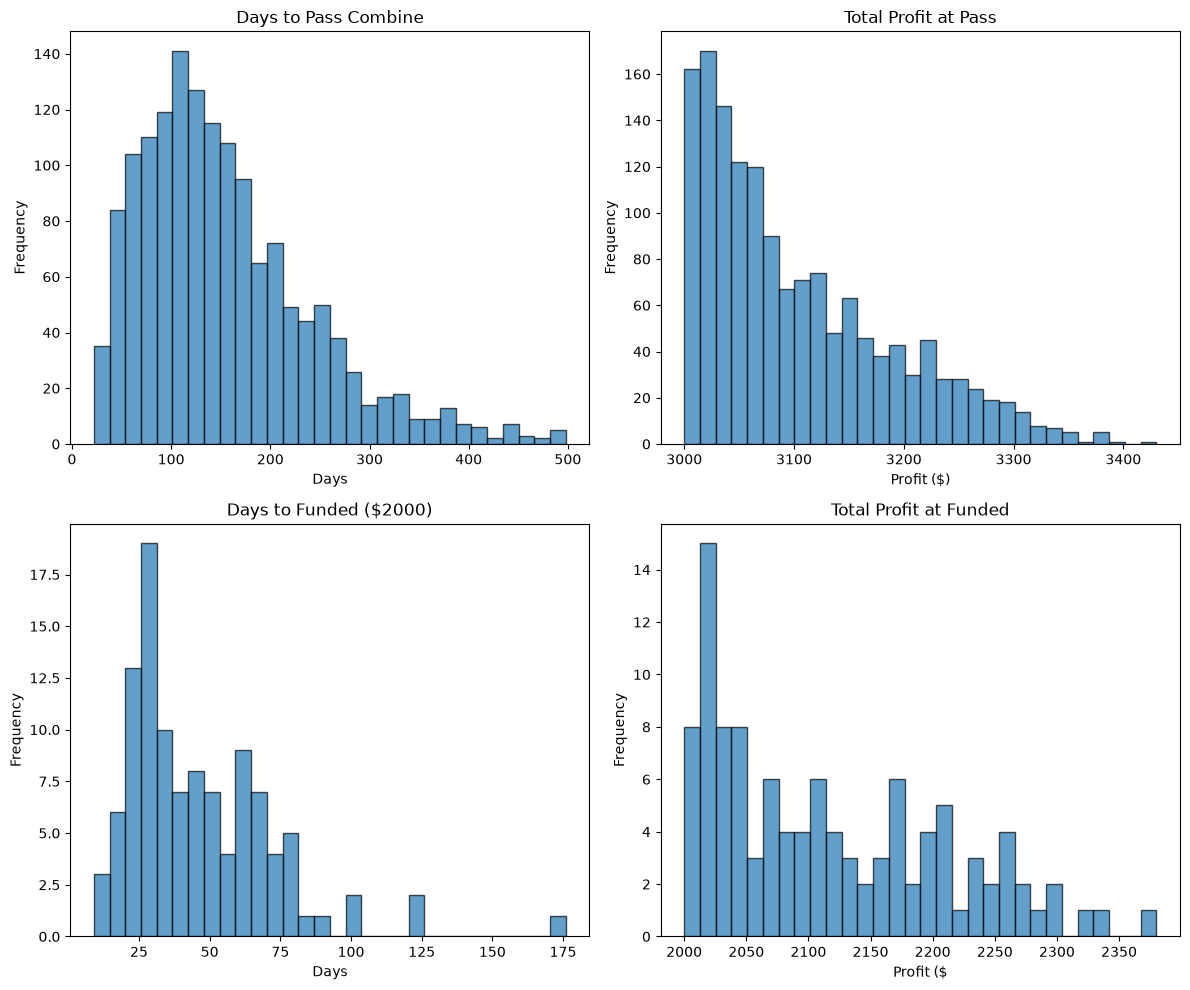

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

if combine_df['passed'].any():
    axes[0, 0].hist(combine_df[combine_df['passed']]['days'], bins=30, alpha=0.7, edgecolor='black')
    axes[0, 0].set_title('Days to Pass Combine')
    axes[0, 1].hist(combine_df[combine_df['passed']]['total_profit'], bins=30, alpha=0.7, edgecolor='black')
    axes[0, 1].set_title('Total Profit at Pass')
else:
    axes[0, 0].text(0.5, 0.5, 'No passes', ha='center', va='center', transform=axes[0, 0].transAxes)
    axes[0, 1].text(0.5, 0.5, 'No passes', ha='center', va='center', transform=axes[0, 1].transAxes)
axes[0, 0].set_xlabel('Days')
axes[0, 0].set_ylabel('Frequency')
axes[0, 1].set_xlabel('Profit ($)')
axes[0, 1].set_ylabel('Frequency')

if xfa_df['funded'].any():
    axes[1, 0].hist(xfa_df[xfa_df['funded']]['days'], bins=30, alpha=0.7, edgecolor='black')
    axes[1, 0].set_title('Days to Funded ($2000)')
    axes[1, 1].hist(xfa_df[xfa_df['funded']]['total_profit'], bins=30, alpha=0.7, edgecolor='black')
    axes[1, 1].set_title('Total Profit at Funded')
else:
    axes[1, 0].text(0.5, 0.5, 'No funded', ha='center', va='center', transform=axes[1, 0].transAxes)
    axes[1, 1].text(0.5, 0.5, 'No funded', ha='center', va='center', transform=axes[1, 1].transAxes)
axes[1, 0].set_xlabel('Days')
axes[1, 0].set_ylabel('Frequency')
axes[1, 1].set_xlabel('Profit ($')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [10]:
free(data, signals)